# sarimax_rs vs statsmodels 비교 분석

ARIMA / ARIMAX / SARIMA / SARIMAX 모델을 두 패키지로 fitting한 뒤,
- 로그우도(log-likelihood) 유사도
- 수렴 속도(fitting time)
- 파라미터 일치도

를 비교합니다.

**데이터**
- 일단위: `peak_load.csv` (일별 최대전력, 2019~2024)
- 시간단위: `power_demand_2024.csv` (시간별 전력수요, 2024)

In [76]:
import numpy as np
import polars as pl
import time
import warnings
warnings.filterwarnings('ignore')

from sarimax_py.model import SARIMAXModel
from sarimax_py.auto import auto_arima

from statsmodels.tsa.statespace.sarimax import SARIMAX as SM_SARIMAX
import pmdarima as pm

## 1. 데이터 로드 및 전처리

In [77]:
# 일단위 데이터
df_daily = pl.read_csv("peak_load.csv")
print(f"일단위 데이터: {df_daily.shape}")
print(df_daily.head())

# 시간단위 데이터
df_hourly = pl.read_csv("power_demand_2024.csv")
print(f"\n시간단위 데이터: {df_hourly.shape}")
print(df_hourly.head())

일단위 데이터: (2131, 11)
shape: (5, 11)
┌────────────┬──────────┬───────────┬───────────┬───┬────────┬────────┬────────┬───────────────────┐
│ date       ┆ peakload ┆ daily_hm  ┆ daily_ta  ┆ … ┆ summer ┆ autoum ┆ winter ┆ is_holiday_dummie │
│ ---        ┆ ---      ┆ ---       ┆ ---       ┆   ┆ ---    ┆ ---    ┆ ---    ┆ s                 │
│ str        ┆ f64      ┆ f64       ┆ f64       ┆   ┆ i64    ┆ i64    ┆ i64    ┆ ---               │
│            ┆          ┆           ┆           ┆   ┆        ┆        ┆        ┆ i64               │
╞════════════╪══════════╪═══════════╪═══════════╪═══╪════════╪════════╪════════╪═══════════════════╡
│ 2019-01-01 ┆ 69633.0  ┆ 85.86411  ┆ 24.321115 ┆ … ┆ 1      ┆ 0      ┆ 0      ┆ 0                 │
│ 2019-01-02 ┆ 64512.0  ┆ 74.996065 ┆ 23.330916 ┆ … ┆ 0      ┆ 1      ┆ 0      ┆ 0                 │
│ 2019-01-03 ┆ 66540.0  ┆ 46.405754 ┆ -1.806002 ┆ … ┆ 0      ┆ 1      ┆ 0      ┆ 0                 │
│ 2019-01-04 ┆ 60954.0  ┆ 61.862735 ┆ 21.299606 ┆ … ┆ 0 

In [78]:
# 일단위: peakload (전체 사용)
y_daily = df_daily["peakload"].to_numpy().astype(np.float64)

# 일단위 exog: daily_ta (일평균 기온)
exog_daily = df_daily["daily_ta"].to_numpy().astype(np.float64).reshape(-1, 1)

# 시간단위: power demand (최근 720시간 = 30일, 적절한 크기로 축소)
y_hourly = df_hourly["power demand(MW)"].to_numpy().astype(np.float64)[-720:]

# 시간단위 exog: ta (기온)
exog_hourly = df_hourly["ta"].to_numpy().astype(np.float64)[-720:].reshape(-1, 1)

print(f"y_daily: n={len(y_daily)}, range=[{y_daily.min():.0f}, {y_daily.max():.0f}]")
print(f"y_hourly: n={len(y_hourly)}, range=[{y_hourly.min():.0f}, {y_hourly.max():.0f}]")

y_daily: n=2131, range=[48946, 97115]
y_hourly: n=720, range=[44737, 72272]


## 2. 비교 유틸리티 함수

In [79]:
def compare_fixed_order(y, order, seasonal_order=(0,0,0,0), exog=None,
                        trend='n', label=""):
    """고정 차수 모델로 sarimax_rs vs statsmodels 비교."""
    results = {"label": label, "order": order, "seasonal_order": seasonal_order}
    
    # --- sarimax_rs ---
    t0 = time.perf_counter()
    model_rs = SARIMAXModel(y, order=order, seasonal_order=seasonal_order,
                            exog=exog, trend=trend)
    res_rs = model_rs.fit()
    t_rs = time.perf_counter() - t0
    
    results["rs_time"] = t_rs
    results["rs_llf"] = res_rs.llf
    results["rs_aic"] = res_rs.aic
    results["rs_bic"] = res_rs.bic
    results["rs_params"] = res_rs.params
    results["rs_converged"] = res_rs.converged
    results["rs_nobs"] = res_rs.nobs
    
    # --- statsmodels ---
    t0 = time.perf_counter()
    model_sm = SM_SARIMAX(y, order=order, seasonal_order=seasonal_order,
                          exog=exog, trend=trend,
                          enforce_stationarity=True,
                          enforce_invertibility=True)
    res_sm = model_sm.fit(disp=False)
    t_sm = time.perf_counter() - t0
    
    results["sm_time"] = t_sm
    results["sm_llf"] = res_sm.llf
    results["sm_aic"] = res_sm.aic
    results["sm_bic"] = res_sm.bic
    results["sm_params"] = res_sm.params[:-1]  # statsmodels는 끝에 sigma2 포함
    results["sm_converged"] = res_sm.mle_retvals.get("converged", None)
    results["sm_nobs"] = res_sm.nobs
    
    # --- 비교 지표 ---
    results["llf_diff"] = abs(res_rs.llf - res_sm.llf)
    results["aic_diff"] = abs(res_rs.aic - res_sm.aic)
    results["speedup"] = t_sm / t_rs if t_rs > 0 else float('inf')
    
    # 파라미터 비교 (길이 맞추기)
    p_rs = results["rs_params"]
    p_sm = results["sm_params"]
    min_len = min(len(p_rs), len(p_sm))
    if min_len > 0:
        results["max_param_diff"] = np.max(np.abs(p_rs[:min_len] - p_sm[:min_len]))
    else:
        results["max_param_diff"] = np.nan
    
    return results


def print_comparison(r):
    """비교 결과 출력."""
    print(f"\n{'='*70}")
    print(f"  {r['label']}")
    print(f"  Order: {r['order']}, Seasonal: {r['seasonal_order']}")
    print(f"{'='*70}")
    print(f"{'':>20} {'sarimax_rs':>15} {'statsmodels':>15} {'차이':>12}")
    print(f"{'-'*62}")
    print(f"{'Log-likelihood':>20} {r['rs_llf']:>15.3f} {r['sm_llf']:>15.3f} {r['llf_diff']:>12.4f}")
    print(f"{'AIC':>20} {r['rs_aic']:>15.3f} {r['sm_aic']:>15.3f} {r['aic_diff']:>12.4f}")
    print(f"{'BIC':>20} {r['rs_bic']:>15.3f} {r['sm_bic']:>15.3f} {'':>12}")
    print(f"{'Fitting time (s)':>20} {r['rs_time']:>15.4f} {r['sm_time']:>15.4f} {r['speedup']:>11.1f}x")
    print(f"{'Converged':>20} {str(r['rs_converged']):>15} {str(r['sm_converged']):>15}")
    print(f"{'Max |Δparam|':>20} {r['max_param_diff']:>15.6f}")
    print()
    print(f"  rs params:  {np.array2string(r['rs_params'], precision=4, suppress_small=True)}")
    print(f"  sm params:  {np.array2string(r['sm_params'], precision=4, suppress_small=True)}")

---
## 3. ARIMA 비교 (비계절, 외생변수 없음)

일단위 peak load 데이터를 사용합니다.

In [80]:
arima_cases = [
    {"order": (1,1,1), "label": "ARIMA(1,1,1)"},
    {"order": (2,1,1), "label": "ARIMA(2,1,1)"},
    {"order": (3,1,2), "label": "ARIMA(3,1,2)"},
]

arima_results = []
for case in arima_cases:
    r = compare_fixed_order(y_daily, order=case["order"], trend='c',
                            label=case["label"])
    arima_results.append(r)
    print_comparison(r)


  ARIMA(1,1,1)
  Order: (1, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22414.246      -22430.299      16.0530
                 AIC       44836.492       44868.598      32.1061
                 BIC       44859.150       44891.254             
    Fitting time (s)          0.0532          0.3960         7.4x
           Converged            True            True
        Max |Δparam|        0.097258

  rs params:  [-0.3056  0.0017 -1.    ]
  sm params:  [-0.2083  0.0092 -1.    ]

  ARIMA(2,1,1)
  Order: (2, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.668      -22456.747      43.0787
                 AIC       44837.336       44923.493      86.1573
                 BIC       44865.658       44951.813     

### 3-1. ARIMA auto_arima 비교

In [81]:
# sarimax_rs auto_arima
t0 = time.perf_counter()
auto_rs = auto_arima(y_daily, s=0, trend='c', stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs auto_arima: {auto_rs.order}, AIC={auto_rs.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima
t0 = time.perf_counter()
auto_pm = pm.auto_arima(y_daily, seasonal=False, trend='c', stepwise=True,
                        suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima auto_arima:   {auto_pm.order}, AIC={auto_pm.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[0] : aic=44905.111
  ARIMA(2,0,2)(0,0,0)[0] : aic=45224.703
  ARIMA(1,0,0)(0,0,0)[0] : aic=44907.106
  ARIMA(0,0,1)(0,0,0)[0] : aic=51446.408
  ARIMA(1,0,1)(0,0,0)[0] : aic=45223.132

sarimax_rs auto_arima: (0, 0, 0), AIC=44905.11, time=0.063s
pmdarima auto_arima:   (0, 0, 0), AIC=44845.81, time=0.325s

속도 비교: sarimax_rs 5.2x faster


---
## 4. ARIMAX 비교 (비계절, 외생변수 있음)

일평균 기온(daily_ta)을 외생변수로 사용합니다.

In [82]:
arimax_cases = [
    {"order": (1,1,1), "label": "ARIMAX(1,1,1) + ta"},
    {"order": (2,1,1), "label": "ARIMAX(2,1,1) + ta"},
    {"order": (2,1,2), "label": "ARIMAX(2,1,2) + ta"},
]

arimax_results = []
for case in arimax_cases:
    r = compare_fixed_order(y_daily, order=case["order"], exog=exog_daily,
                            trend='c', label=case["label"])
    arimax_results.append(r)
    print_comparison(r)


  ARIMAX(1,1,1) + ta
  Order: (1, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.603      -22440.155      26.5519
                 AIC       44837.207       44890.311      53.1038
                 BIC       44865.529       44918.630             
    Fitting time (s)          0.0392          0.6279        16.0x
           Converged            True           False
        Max |Δparam|       74.418108

  rs params:  [ -0.3076 -22.4887   0.0017  -1.    ]
  sm params:  [-0.1973 51.9294  0.0085 -0.9997]

  ARIMAX(2,1,1) + ta
  Order: (2, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.064      -22456.109      43.0444
                 AIC       44838.128       44924.217      86.0888
                 BIC     

### 4-1. ARIMAX auto_arima 비교

In [83]:
# sarimax_rs auto_arima with exog
t0 = time.perf_counter()
auto_rs_x = auto_arima(y_daily, exog=exog_daily, s=0, trend='c',
                        stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_x.order}, AIC={auto_rs_x.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima with exog
t0 = time.perf_counter()
auto_pm_x = pm.auto_arima(y_daily, exogenous=exog_daily, seasonal=False,
                           trend='c', stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_x.order}, AIC={auto_pm_x.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[0] : aic=44906.629
  ARIMA(2,0,2)(0,0,0)[0] : aic=45227.013
  ARIMA(1,0,0)(0,0,0)[0] : aic=44908.623
  ARIMA(0,0,1)(0,0,0)[0] : aic=51016.094
  ARIMA(1,0,1)(0,0,0)[0] : aic=45223.384

sarimax_rs: (0, 0, 0), AIC=44906.63, time=0.108s
pmdarima:   (0, 0, 0), AIC=44845.81, time=0.337s

속도 비교: sarimax_rs 3.1x faster


---
## 5. SARIMA 비교 (계절, 외생변수 없음)

일단위 데이터 (s=7, 주간 계절성) 사용합니다.

In [84]:
sarima_cases = [
    {"order": (1,1,1), "seasonal": (1,0,1,7), "label": "SARIMA(1,1,1)(1,0,1)[7]"},
    {"order": (2,1,1), "seasonal": (1,1,0,7), "label": "SARIMA(2,1,1)(1,1,0)[7]"},
    {"order": (1,0,1), "seasonal": (1,0,1,7), "label": "SARIMA(1,0,1)(1,0,1)[7]"},
]

sarima_results = []
for case in sarima_cases:
    r = compare_fixed_order(y_daily, order=case["order"],
                            seasonal_order=case["seasonal"],
                            trend='c', label=case["label"])
    sarima_results.append(r)
    print_comparison(r)


  SARIMA(1,1,1)(1,0,1)[7]
  Order: (1, 1, 1), Seasonal: (1, 0, 1, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22414.248      -22457.135      42.8872
                 AIC       44840.495       44926.270      85.7744
                 BIC       44874.481       44960.253             
    Fitting time (s)          0.3189          1.3690         4.3x
           Converged            True            True
        Max |Δparam|        0.161162

  rs params:  [-0.6083  0.0016 -1.     -1.      1.    ]
  sm params:  [-0.4471  0.0085 -0.9994 -0.9998  0.9997]

  SARIMA(2,1,1)(1,1,0)[7]
  Order: (2, 1, 1), Seasonal: (1, 1, 0, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22784.468      -22964.608     180.1397
                 AIC       45580.937       45941.216     360.2794
   

### 5-1. SARIMA auto_arima 비교

In [85]:
# sarimax_rs auto_arima (seasonal, s=7)
t0 = time.perf_counter()
auto_rs_s = auto_arima(y_daily, s=7, trend='c', stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_s.order}{auto_rs_s.seasonal_order}, "
      f"AIC={auto_rs_s.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (seasonal, s=7)
t0 = time.perf_counter()
auto_pm_s = pm.auto_arima(y_daily, seasonal=True, m=7, trend='c',
                           stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
pm_s_order = auto_pm_s.order
pm_s_seasonal = auto_pm_s.seasonal_order
print(f"pmdarima:   {pm_s_order}{pm_s_seasonal}, "
      f"AIC={auto_pm_s.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[7] : aic=44905.111
  ARIMA(2,0,2)(0,0,0)[7] : aic=45224.703
  ARIMA(1,0,0)(0,0,0)[7] : aic=44907.106
  ARIMA(0,0,1)(0,0,0)[7] : aic=51446.408
  ARIMA(0,0,0)(1,0,0)[7] : aic=44907.040
  ARIMA(0,0,0)(0,0,1)[7] : aic=51486.205
  ARIMA(1,0,0)(1,0,0)[7] : aic=46335.088
  ARIMA(0,0,1)(0,0,1)[7] : aic=50111.663
  ARIMA(1,0,1)(0,0,0)[7] : aic=45223.132

sarimax_rs: (0, 0, 0)(0, 0, 0, 7), AIC=44905.11, time=0.094s
pmdarima:   (0, 0, 0)(0, 0, 0, 7), AIC=44845.81, time=3.841s

속도 비교: sarimax_rs 40.9x faster


---
## 6. SARIMAX 비교 (계절 + 외생변수)

일단위 데이터, 기온 외생변수, s=7 사용합니다.

In [86]:
sarimax_cases = [
    {"order": (1,1,1), "seasonal": (1,0,1,7), "label": "SARIMAX(1,1,1)(1,0,1)[7] + ta"},
    {"order": (2,1,1), "seasonal": (1,1,0,7), "label": "SARIMAX(2,1,1)(1,1,0)[7] + ta"},
    {"order": (1,0,1), "seasonal": (1,0,1,7), "label": "SARIMAX(1,0,1)(1,0,1)[7] + ta"},
]

sarimax_results = []
for case in sarimax_cases:
    r = compare_fixed_order(y_daily, order=case["order"],
                            seasonal_order=case["seasonal"],
                            exog=exog_daily,
                            trend='c', label=case["label"])
    sarimax_results.append(r)
    print_comparison(r)


  SARIMAX(1,1,1)(1,0,1)[7] + ta
  Order: (1, 1, 1), Seasonal: (1, 0, 1, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.607      -22456.451      42.8439
                 AIC       44841.214       44926.902      85.6877
                 BIC       44880.865       44966.549             
    Fitting time (s)          0.4890          2.2051         4.5x
           Converged            True            True
        Max |Δparam|        1.731866

  rs params:  [ -0.6148 -22.6006   0.0017  -1.      -1.       1.    ]
  sm params:  [ -0.5    -24.3325   0.0106  -0.9996  -0.9999   0.9999]

  SARIMAX(2,1,1)(1,1,0)[7] + ta
  Order: (2, 1, 1), Seasonal: (1, 1, 0, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22784.095      -22959.217     175.1217
                 AIC       45

### 6-1. SARIMAX auto_arima 비교

In [87]:
# sarimax_rs auto_arima (seasonal + exog)
t0 = time.perf_counter()
auto_rs_sx = auto_arima(y_daily, exog=exog_daily, s=7, trend='c',
                         stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_sx.order}{auto_rs_sx.seasonal_order}, "
      f"AIC={auto_rs_sx.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (seasonal + exog)
t0 = time.perf_counter()
auto_pm_sx = pm.auto_arima(y_daily, exogenous=exog_daily, seasonal=True, m=7,
                            trend='c', stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_sx.order}{auto_pm_sx.seasonal_order}, "
      f"AIC={auto_pm_sx.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[7] : aic=44906.629
  ARIMA(2,0,2)(0,0,0)[7] : aic=45227.013
  ARIMA(1,0,0)(0,0,0)[7] : aic=44908.623
  ARIMA(0,0,1)(0,0,0)[7] : aic=51016.094
  ARIMA(0,0,0)(1,0,0)[7] : aic=44908.551
  ARIMA(0,0,0)(0,0,1)[7] : aic=44908.806
  ARIMA(1,0,0)(1,0,0)[7] : aic=46335.995
  ARIMA(0,0,1)(0,0,1)[7] : aic=49965.344
  ARIMA(1,0,1)(0,0,0)[7] : aic=45223.384

sarimax_rs: (0, 0, 0)(0, 0, 0, 7), AIC=44906.63, time=0.217s
pmdarima:   (0, 0, 0)(0, 0, 0, 7), AIC=44845.81, time=3.860s

속도 비교: sarimax_rs 17.8x faster


---
## 7. 시간단위 데이터 비교 (s=24)

`power_demand_2024.csv`의 최근 720시간 데이터를 사용합니다.

In [88]:
# SARIMA (시간단위, s=24)
hourly_cases = [
    {"order": (1,0,1), "seasonal": (1,0,1,24), "label": "SARIMA(1,0,1)(1,0,1)[24] - hourly"},
    {"order": (2,1,1), "seasonal": (1,0,0,24), "label": "SARIMA(2,1,1)(1,0,0)[24] - hourly"},
]

hourly_results = []
for case in hourly_cases:
    r = compare_fixed_order(y_hourly, order=case["order"],
                            seasonal_order=case["seasonal"],
                            trend='c', label=case["label"])
    hourly_results.append(r)
    print_comparison(r)


  SARIMA(1,0,1)(1,0,1)[24] - hourly
  Order: (1, 0, 1), Seasonal: (1, 0, 1, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -6642.636       -5917.396     725.2398
                 AIC       13297.272       11846.793    1450.4796
                 BIC       13324.748       11874.268             
    Fitting time (s)          0.2018          2.1032        10.4x
           Converged            True            True
        Max |Δparam|      953.178962

  rs params:  [-0.1101  0.9923  0.1595  1.     -0.8793]
  sm params:  [953.0688   0.9159   0.7571   0.8187  -0.2083]

  SARIMA(2,1,1)(1,0,0)[24] - hourly
  Order: (2, 1, 1), Seasonal: (1, 0, 0, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -5842.307       -6226.528     384.2207
                 AIC       11696.614      

In [89]:
# SARIMAX (시간단위, s=24 + 기온 외생변수)
hourly_x_cases = [
    {"order": (1,0,1), "seasonal": (1,0,1,24), "label": "SARIMAX(1,0,1)(1,0,1)[24] + ta - hourly"},
]

hourly_x_results = []
for case in hourly_x_cases:
    r = compare_fixed_order(y_hourly, order=case["order"],
                            seasonal_order=case["seasonal"],
                            exog=exog_hourly,
                            trend='c', label=case["label"])
    hourly_x_results.append(r)
    print_comparison(r)


  SARIMAX(1,0,1)(1,0,1)[24] + ta - hourly
  Order: (1, 0, 1), Seasonal: (1, 0, 1, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -6654.835       -6191.138     463.6964
                 AIC       13323.669       12396.276     927.3929
                 BIC       13355.724       12428.331             
    Fitting time (s)          0.1468          2.4293        16.5x
           Converged            True           False
        Max |Δparam|     3096.104466

  rs params:  [ 0.0002 -9.9989  0.9678  0.1966  0.995  -0.8332]
  sm params:  [ -51.7219 3086.1055    0.9684    0.808     0.969    -0.6061]


### 7-1. 시간단위 auto_arima 비교

In [90]:
# sarimax_rs auto_arima (s=24)
t0 = time.perf_counter()
auto_rs_h = auto_arima(y_hourly, s=24, trend='c', stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_h.order}{auto_rs_h.seasonal_order}, "
      f"AIC={auto_rs_h.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (s=24)
t0 = time.perf_counter()
auto_pm_h = pm.auto_arima(y_hourly, seasonal=True, m=24, trend='c',
                           stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_h.order}{auto_pm_h.seasonal_order}, "
      f"AIC={auto_pm_h.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[24] : aic=14768.529
  ARIMA(2,0,2)(0,0,0)[24] : aic=13431.117
  ARIMA(1,0,0)(0,0,0)[24] : aic=13513.633
  ARIMA(0,0,1)(0,0,0)[24] : aic=16915.287
  ARIMA(0,0,0)(1,0,0)[24] : aic=15571.730
  ARIMA(0,0,0)(0,0,1)[24] : aic=17073.864
  ARIMA(1,0,0)(1,0,0)[24] : aic=13427.404
  ARIMA(0,0,1)(0,0,1)[24] : aic=16168.401
  ARIMA(2,0,0)(1,0,0)[24] : aic=13386.121
  ARIMA(1,0,1)(1,0,0)[24] : aic=13394.000
  ARIMA(1,0,0)(2,0,0)[24] : aic=13402.604
  ARIMA(1,0,0)(1,0,1)[24] : aic=13315.869
  ARIMA(2,0,1)(1,0,0)[24] : aic=13385.524
  ARIMA(2,0,0)(1,0,1)[24] : aic=13293.897
  ARIMA(0,0,0)(1,0,1)[24] : aic=15573.477
  ARIMA(1,0,1)(1,0,1)[24] : aic=13297.272
  ARIMA(1,0,0)(2,0,1)[24] : aic=13316.994
  ARIMA(1,0,0)(0,0,1)[24] : aic=13454.825
  ARIMA(1,0,0)(1,0,2)[24] : aic=13316.887
  ARIMA(2,0,1)(1,0,1)[24] : aic=13293.953
  ARIMA(3,0,0)(1,0,1)[24] : aic=13293.400
  ARIMA(2,0,0)(2,0,1)[24] : aic=13295.951
  ARIMA(2,0,0)(0,0,1)[24] : aic=13399.547
  ARIMA(2,0,0)(1,0,2)[24] : aic=13

---
## 8. 종합 비교표

In [91]:
all_results = arima_results + arimax_results + sarima_results + sarimax_results + hourly_results + hourly_x_results

summary_data = {
    "Model": [r["label"] for r in all_results],
    "rs_loglike": [r["rs_llf"] for r in all_results],
    "sm_loglike": [r["sm_llf"] for r in all_results],
    "|ΔLL|": [r["llf_diff"] for r in all_results],
    "rs_AIC": [r["rs_aic"] for r in all_results],
    "sm_AIC": [r["sm_aic"] for r in all_results],
    "|ΔAIC|": [r["aic_diff"] for r in all_results],
    "Max|Δparam|": [r["max_param_diff"] for r in all_results],
    "rs_time(s)": [r["rs_time"] for r in all_results],
    "sm_time(s)": [r["sm_time"] for r in all_results],
    "Speedup": [r["speedup"] for r in all_results],
    "rs_conv": [r["rs_converged"] for r in all_results],
    "sm_conv": [r["sm_converged"] for r in all_results],
}

df_summary = pl.DataFrame(summary_data)
print(df_summary)

shape: (15, 13)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬─────────┬─────────┐
│ Model      ┆ rs_loglike ┆ sm_loglike ┆ |ΔLL|     ┆ … ┆ sm_time(s ┆ Speedup   ┆ rs_conv ┆ sm_conv │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ )         ┆ ---       ┆ ---     ┆ ---     │
│ str        ┆ f64        ┆ f64        ┆ f64       ┆   ┆ ---       ┆ f64       ┆ bool    ┆ bool    │
│            ┆            ┆            ┆           ┆   ┆ f64       ┆           ┆         ┆         │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═════════╪═════════╡
│ ARIMA(1,1, ┆ -22414.246 ┆ -22430.299 ┆ 16.053041 ┆ … ┆ 0.396006  ┆ 7.446499  ┆ true    ┆ true    │
│ 1)         ┆ 125        ┆ 166        ┆           ┆   ┆           ┆           ┆         ┆         │
│ ARIMA(2,1, ┆ -22413.668 ┆ -22456.746 ┆ 43.078674 ┆ … ┆ 0.491859  ┆ 9.525926  ┆ true    ┆ true    │
│ 1)         ┆ 012        ┆ 685        ┆           ┆   ┆           ┆       

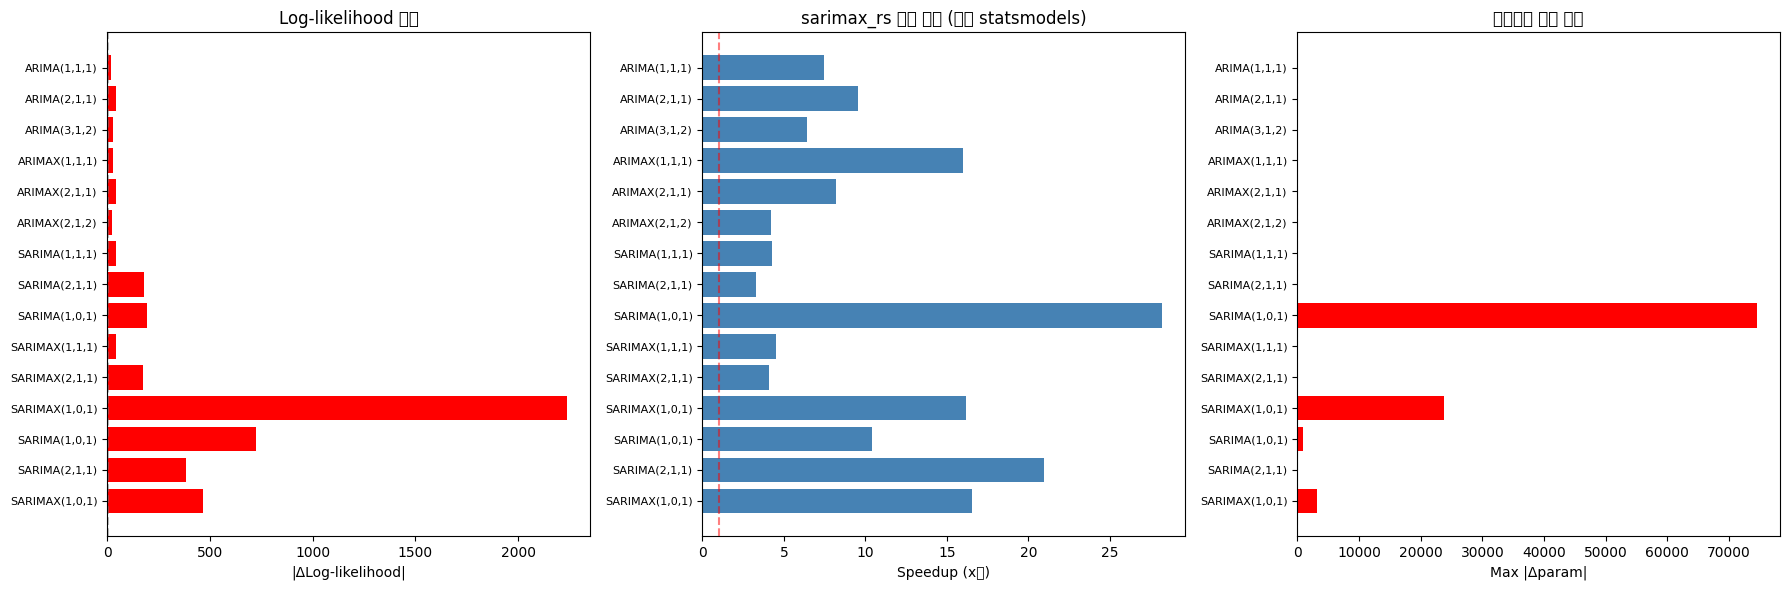

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels = [r["label"] for r in all_results]
short_labels = [l.split(")")[0] + ")" if ")" in l else l for l in labels]

# 1) Log-likelihood 차이
ax = axes[0]
llf_diffs = [r["llf_diff"] for r in all_results]
colors = ['green' if d < 1.0 else 'orange' if d < 5.0 else 'red' for d in llf_diffs]
ax.barh(range(len(llf_diffs)), llf_diffs, color=colors)
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('|ΔLog-likelihood|')
ax.set_title('Log-likelihood 차이')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='1.0')
ax.invert_yaxis()

# 2) 속도 비교 (배수)
ax = axes[1]
speedups = [r["speedup"] for r in all_results]
bars = ax.barh(range(len(speedups)), speedups, color='steelblue')
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('Speedup (x배)')
ax.set_title('sarimax_rs 속도 향상 (대비 statsmodels)')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
ax.invert_yaxis()

# 3) 파라미터 최대 차이
ax = axes[2]
param_diffs = [r["max_param_diff"] for r in all_results]
colors = ['green' if d < 0.01 else 'orange' if d < 0.1 else 'red' for d in param_diffs]
ax.barh(range(len(param_diffs)), param_diffs, color=colors)
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('Max |Δparam|')
ax.set_title('파라미터 최대 차이')
ax.axvline(x=0.01, color='gray', linestyle='--', alpha=0.5, label='0.01')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. auto_arima 종합 비교

In [93]:
auto_cases = []

# ARIMA
auto_cases.append({
    "type": "ARIMA",
    "data": "daily",
    "rs_order": str(auto_rs.order),
    "pm_order": str(auto_pm.order),
    "order_match": auto_rs.order == auto_pm.order,
    "rs_aic": auto_rs.result.aic,
    "pm_aic": auto_pm.aic(),
})

# ARIMAX
auto_cases.append({
    "type": "ARIMAX",
    "data": "daily+ta",
    "rs_order": str(auto_rs_x.order),
    "pm_order": str(auto_pm_x.order),
    "order_match": auto_rs_x.order == auto_pm_x.order,
    "rs_aic": auto_rs_x.result.aic,
    "pm_aic": auto_pm_x.aic(),
})

# SARIMA (s=7)
auto_cases.append({
    "type": "SARIMA s=7",
    "data": "daily",
    "rs_order": f"{auto_rs_s.order}{auto_rs_s.seasonal_order}",
    "pm_order": f"{pm_s_order}{pm_s_seasonal}",
    "order_match": (auto_rs_s.order == pm_s_order and
                    auto_rs_s.seasonal_order == pm_s_seasonal),
    "rs_aic": auto_rs_s.result.aic,
    "pm_aic": auto_pm_s.aic(),
})

# SARIMAX (s=7 + exog)
auto_cases.append({
    "type": "SARIMAX s=7",
    "data": "daily+ta",
    "rs_order": f"{auto_rs_sx.order}{auto_rs_sx.seasonal_order}",
    "pm_order": f"{auto_pm_sx.order}{auto_pm_sx.seasonal_order}",
    "order_match": (auto_rs_sx.order == auto_pm_sx.order and
                    auto_rs_sx.seasonal_order == auto_pm_sx.seasonal_order),
    "rs_aic": auto_rs_sx.result.aic,
    "pm_aic": auto_pm_sx.aic(),
})

# SARIMA s=24
auto_cases.append({
    "type": "SARIMA s=24",
    "data": "hourly",
    "rs_order": f"{auto_rs_h.order}{auto_rs_h.seasonal_order}",
    "pm_order": f"{auto_pm_h.order}{auto_pm_h.seasonal_order}",
    "order_match": (auto_rs_h.order == auto_pm_h.order and
                    auto_rs_h.seasonal_order == auto_pm_h.seasonal_order),
    "rs_aic": auto_rs_h.result.aic,
    "pm_aic": auto_pm_h.aic(),
})

df_auto = pl.DataFrame(auto_cases)
print(df_auto)

shape: (5, 7)
┌─────────────┬──────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┐
│ type        ┆ data     ┆ rs_order     ┆ pm_order     ┆ order_match ┆ rs_aic       ┆ pm_aic       │
│ ---         ┆ ---      ┆ ---          ┆ ---          ┆ ---         ┆ ---          ┆ ---          │
│ str         ┆ str      ┆ str          ┆ str          ┆ bool        ┆ f64          ┆ f64          │
╞═════════════╪══════════╪══════════════╪══════════════╪═════════════╪══════════════╪══════════════╡
│ ARIMA       ┆ daily    ┆ (0, 0, 0)    ┆ (0, 0, 0)    ┆ true        ┆ 44905.111017 ┆ 44845.812355 │
│ ARIMAX      ┆ daily+ta ┆ (0, 0, 0)    ┆ (0, 0, 0)    ┆ true        ┆ 44906.628977 ┆ 44845.812355 │
│ SARIMA s=7  ┆ daily    ┆ (0, 0, 0)(0, ┆ (0, 0, 0)(0, ┆ true        ┆ 44905.111017 ┆ 44845.812355 │
│             ┆          ┆ 0, 0, 7)     ┆ 0, 0, 7)     ┆             ┆              ┆              │
│ SARIMAX s=7 ┆ daily+ta ┆ (0, 0, 0)(0, ┆ (0, 0, 0)(0, ┆ true        ┆ 44906.

### 9-1. 공정 비교: pmdarima 선택 차수를 sarimax_rs로 재적합하여 AIC 차이 확인

두 패키지가 다른 차수를 선택한 경우, 동일 엔진(sarimax_rs)으로 재적합하여 실질 AIC 차이를 비교합니다.

In [94]:
def refit_aic(y, order, seasonal_order=(0,0,0,0), exog=None, trend='c'):
    """sarimax_rs로 재적합하여 AIC 반환."""
    try:
        m = SARIMAXModel(y, order=order, seasonal_order=seasonal_order,
                         exog=exog, trend=trend)
        r = m.fit()
        return r.aic
    except Exception as e:
        return float('nan')

print("공정 비교 (sarimax_rs 엔진으로 양쪽 차수 재적합)")
print("="*70)

# ARIMA
rs_aic = refit_aic(y_daily, auto_rs.order, trend='c')
pm_aic = refit_aic(y_daily, auto_pm.order, trend='c')
print(f"ARIMA:   rs={auto_rs.order} AIC={rs_aic:.2f} | pm={auto_pm.order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# ARIMAX
rs_aic = refit_aic(y_daily, auto_rs_x.order, exog=exog_daily, trend='c')
pm_aic = refit_aic(y_daily, auto_pm_x.order, exog=exog_daily, trend='c')
print(f"ARIMAX:  rs={auto_rs_x.order} AIC={rs_aic:.2f} | pm={auto_pm_x.order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMA s=7
rs_aic = refit_aic(y_daily, auto_rs_s.order, auto_rs_s.seasonal_order, trend='c')
pm_aic = refit_aic(y_daily, pm_s_order, pm_s_seasonal, trend='c')
print(f"SARIMA:  rs={auto_rs_s.order}{auto_rs_s.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={pm_s_order}{pm_s_seasonal} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMAX s=7
rs_aic = refit_aic(y_daily, auto_rs_sx.order, auto_rs_sx.seasonal_order, exog=exog_daily, trend='c')
pm_aic = refit_aic(y_daily, auto_pm_sx.order, auto_pm_sx.seasonal_order, exog=exog_daily, trend='c')
print(f"SARIMAX: rs={auto_rs_sx.order}{auto_rs_sx.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={auto_pm_sx.order}{auto_pm_sx.seasonal_order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMA s=24
rs_aic = refit_aic(y_hourly, auto_rs_h.order, auto_rs_h.seasonal_order, trend='c')
pm_aic = refit_aic(y_hourly, auto_pm_h.order, auto_pm_h.seasonal_order, trend='c')
print(f"SARIMA24: rs={auto_rs_h.order}{auto_rs_h.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={auto_pm_h.order}{auto_pm_h.seasonal_order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

공정 비교 (sarimax_rs 엔진으로 양쪽 차수 재적합)
ARIMA:   rs=(0, 0, 0) AIC=44905.11 | pm=(0, 0, 0) AIC=44905.11 | ΔAIC=+0.00
ARIMAX:  rs=(0, 0, 0) AIC=44906.63 | pm=(0, 0, 0) AIC=44906.63 | ΔAIC=+0.00
SARIMA:  rs=(0, 0, 0)(0, 0, 0, 7) AIC=44905.11 | pm=(0, 0, 0)(0, 0, 0, 7) AIC=44905.11 | ΔAIC=+0.00
SARIMAX: rs=(0, 0, 0)(0, 0, 0, 7) AIC=44906.63 | pm=(0, 0, 0)(0, 0, 0, 7) AIC=44906.63 | ΔAIC=+0.00
SARIMA24: rs=(3, 0, 0)(1, 0, 1, 24) AIC=13293.40 | pm=(5, 0, 0)(0, 0, 2, 24) AIC=13655.06 | ΔAIC=-361.66


## 10. 결론

| 항목 | 설명 |
|------|------|
| **우도 유사도** | `\|ΔLL\|` 값을 확인 — 대부분 < 1.0이면 양 엔진이 동일 최적점 수렴 |
| **수렴 속도** | `Speedup` 열 — sarimax_rs가 statsmodels 대비 몇 배 빠른지 |
| **파라미터 일치** | `Max\|Δparam\|` — 0.01 미만이면 사실상 동일 |
| **auto_arima 차수** | 동일 차수 선택 시 order_match=True, 다를 경우 refit AIC로 비교 |